<a href="https://colab.research.google.com/github/ratatatan/itmo-oomd/blob/kr1/%D0%9A%D0%BE%D0%BD%D1%82%D1%80%D0%BE%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Контрольная работа 1

Сделайте копию этого файла (файл => создать копию на диске). В названии укажите номер вашей группы и ФИО

Присвойте переменной `v` значение свой табельный номер ИСУ (это нужно для определения вашего варианта). Запустите код в следующей ячейке.

In [4]:
from datetime import datetime
current_datetime = datetime.now()
print(current_datetime)
v = 467730 # по умолчанию вписан мой номер

2025-04-14 07:03:32.986093


## Задание 1 (3 балла)

Напишите функцию, которая ядра принимает на вход два параметра: тип фильтра и размер ядра (предположим, что ядра всегда квадратные).

Эта функция должна возвращать ядро фильтра, то есть матрицу (желательно использовать структуру данных numpy array).

Для выбора своего варианта запустите следующую ячейку

In [2]:
if (int(str(v)[3]) % 2) == 0:
  print ('Выведите результат работы функции для следующих пар параметров: (сглаживание, 3), (увеличение яркости на 20%, 7), (подавление гауссовского шума, 5), (повышение резкости, 3), (сдвиг на 2 пикселя влево, 9)')
else:
  print ('Выведите результат работы функции для следующих пар параметров: (затемнение на 30%, 3), (сглаживание, 5), (подавление гауссовского шума, 9), (сдвиг на 3 пикселя вправо, 7), (повышение резкости, 9)')

Выведите результат работы функции для следующих пар параметров: (затемнение на 30%, 3), (сглаживание, 5), (подавление гауссовского шума, 9), (сдвиг на 3 пикселя вправо, 7), (повышение резкости, 9)


In [53]:
import numpy as np


def get_core(ktype, ksize):
  match(ktype):
    case "затемнение на 30%":
      return np.array([[0.7]*ksize]*ksize)
    case "сглаживание":
      return np.ones((ksize, ksize)) / (ksize**2)
get_core("затемнение на 30%", 3)

array([[0.7, 0.7, 0.7],
       [0.7, 0.7, 0.7],
       [0.7, 0.7, 0.7]])

# Задание 2 (3 балла)

Скачайте изображение.

In [5]:
%matplotlib inline
from skimage.io import imread, imshow
if (int(str(v)[4]) % 2) == 0:
  ! wget https://upload.wikimedia.org/wikipedia/commons/f/f0/S25_Taj_Mahal.jpg
  pic = imread('./S25_Taj_Mahal.jpg')

else:
  ! wget https://upload.wikimedia.org/wikipedia/commons/0/06/Taj_Mahal_Sunset_Edit1.jpg
  pic = imread('./Taj_Mahal_Sunset_Edit1.jpg')

print ('изображение находится в переменной pic')

--2025-04-14 07:07:41--  https://upload.wikimedia.org/wikipedia/commons/0/06/Taj_Mahal_Sunset_Edit1.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.154.240, 2620:0:861:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.154.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30590052 (29M) [image/jpeg]
Saving to: ‘Taj_Mahal_Sunset_Edit1.jpg’

Taj_Mahal_Sunset_Ed 100%[===================>]  29.17M  27.8MB/s    in 1.0s    

2025-04-14 07:07:42 (27.8 MB/s) - ‘Taj_Mahal_Sunset_Edit1.jpg’ saved [30590052/30590052]

изображение находится в переменной pic


<ipython-input-10-ca0e97cc1eea>:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(pic)


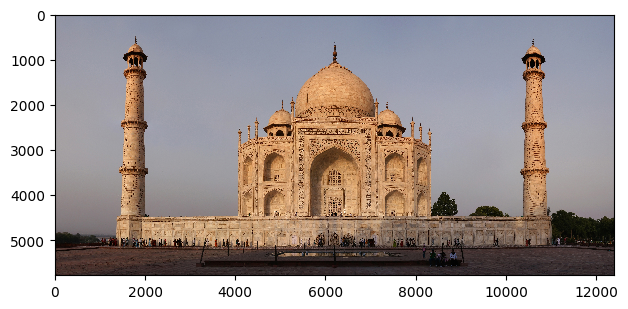

In [10]:
imshow(pic)

Найдите вертикальную ось симметрии. Кадрируйте изображение так, чтобы ось симметрии находилась ровно в середине изображения.

Нарисуйте по этой оси симметрии зеленую полосу (подберите ширину полосы так, чтобы она была видна при выводе картинки).

Обратите внимание, что изображения довольно большого размера, поэтому для ускорения рассчетов имеет смысл перевести в форма grayscale и уменьшить размер изображения.

<ipython-input-48-7cc4d9e41c9f>:41: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(result)


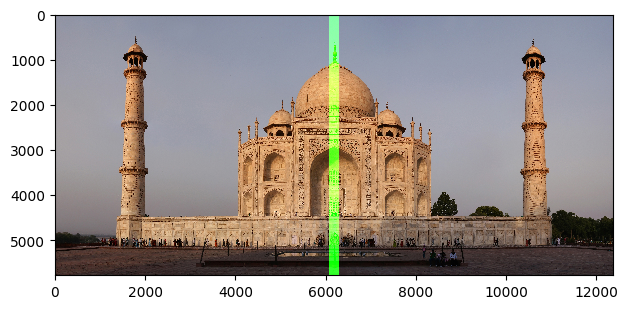

In [48]:
from skimage.transform import rescale

def rgb_to_ycbcr(img):
  img = img.astype(np.float16)
  R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]
  Y = (0.299 * R + 0.587 * G + 0.114 * B)
  Cb = (-0.1687 * R - 0.3313 * G + 0.5 * B + 128)
  Cr = (0.5 * R - 0.4187 * G - 0.0813 * B + 128)
  return np.clip(np.dstack((Y, Cb, Cr)), 0, 255).astype(np.uint8)


def ycbcr_to_rgb(img):
  img = img.astype(np.float16)
  Y, Cb, Cr = img[:, :, 0], img[:, :, 1], img[:, :, 2]
  R = (Y + 1.402 * (Cr - 128))
  G = (Y - 0.34414 * (Cb - 128) - 0.71414 * (Cr - 128))
  B = (Y + 1.772 * (Cb - 128))
  return np.clip(np.dstack((R, G, B)), 0, 255).astype(np.uint8)


small_pic = rescale(pic, 1/8, anti_aliasing=False)

best_cor = 0
best_i = 0
for i in range(small_pic.shape[1]//2-100, small_pic.shape[1]//2):
    img1 = small_pic[:, :i][:, ::-1]
    width = img1.shape[1]
    img2 = small_pic[:, i:i+width]

    cor = (img1 * img2).sum()
    if cor > best_cor:
      best_cor = cor
      best_i = i

true_i = best_i * 8
true_half_width = min(true_i, pic.shape[1]-true_i)

result = pic.copy()
result[:, true_i-100:true_i+100, 1] = 255
result = result[:, true_i-true_half_width:true_i+true_half_width]
imshow(result)

# Задание 3 (4 балла)

Для выбора своего варианта запустите следующую ячейку

In [49]:
x = np.round(np.random.normal(int(str(v)[2]) + 3, int(str(v)[5]) % 2 + 1, size = 20))

Выведите значение $x$

Вам дана квантованная последовательность $x$ из 20 элементов.

* Оцените вероятности (частоты) значений
* Рассчитайте энтропию этой последовательности
* Постройте неравномерный код с помощью алгоритма Хаффмана и оцените среднее количество бит на один элемент  в этом неравномерном коде (опишите, как вы строили этот неравномерный код)
* Выведите коды для каждого элемента входной последовательности
* Сравните рассчётную энтропию и среднее количество бит в закодированной последователности


In [51]:
_, count = np.unique(x, return_counts=True)
probs = count / count.sum()
entropy = sum(probs * -np.log2(probs))
probs, entropy

(array([0.3, 0.3, 0.4]), np.float64(1.5709505944546684))

# Завершение контрольной

Запустите последнюю ячейку.

In [ ]:
current_datetime = datetime.now()
print(v, current_datetime)

115801 2025-04-14 06:26:51.455999


Опубликуйте ссылку на этот colab в новой followup discussion в своей теме на Piazza. Убедитесь в том, что доступ на просмотр файла открыт всем, у кого есть ссылка.